In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter
from matplotlib.colors import Normalize
from mplsoccer import Pitch, Radar, FontManager, grid

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import json
import pandas as pd
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager

from matplotlib.font_manager import FontProperties
from bs4 import BeautifulSoup
import cloudscraper
import pandas as pd
from io import StringIO
from mplsoccer import Radar, FontManager, grid

In [2]:
def get_player_points(url):
    options = webdriver.ChromeOptions()
    options.set_capability(
        'goog:loggingPrefs', {"performance": "ALL", "browser": "ALL"}
    )

    driver = webdriver.Chrome(
        service=ChromeService(ChromeDriverManager().install()),
        options=options
    )
    driver.set_page_load_timeout(10)

    try:
        driver.get(
            url
        )
    except:
        pass

    # 🔴 IMPORTANTE: scroll para que se dispare el fetch del heatmap
    driver.execute_script(
        "window.scrollTo(0, document.body.scrollHeight);"
    )

    # leer logs de red
    logs_raw = driver.get_log("performance")
    logs = [json.loads(lr['message'])['message'] for lr in logs_raw]

    # buscar el endpoint de HEATMAP
    for x in logs:
        path = x['params'].get('headers', {}).get(':path', '')
        if 'heatmap' in path and 'player' in path:
            print(path)
            break

    # obtener el body REAL
    heatmap_data = json.loads(
        driver.execute_cdp_cmd(
            'Network.getResponseBody',
            {'requestId': x['params']['requestId']}
        )['body']
    )

    driver.quit()


    df = heatmap_data['points']
    df = [{"x": p["x"], "y": p["y"]} for p in df]
    df = pd.DataFrame(df)
    
    return df

In [3]:
url = 'https://www.sofascore.com/es-la/football/player/lamine-yamal/1402912#tab:season' 
df_lamine  = get_player_points(url)

/api/v1/player/1402912/unique-tournament/7/season/76953/heatmap/overall


In [4]:
sofascore_cmap = LinearSegmentedColormap.from_list(
    "sofascore",
    [
        "#22312b",  # fondo (verde campo)
        "#2e7d32",  # verde oscuro
        "#66bb6a",  # verde claro
        "#cddc39",  # amarillo verdoso
        "#ffeb3b",  # amarillo
        "#ffb300",  # naranja
        "#f57c00",  # naranja fuerte
        "#e53935",  # rojo
    ]
)

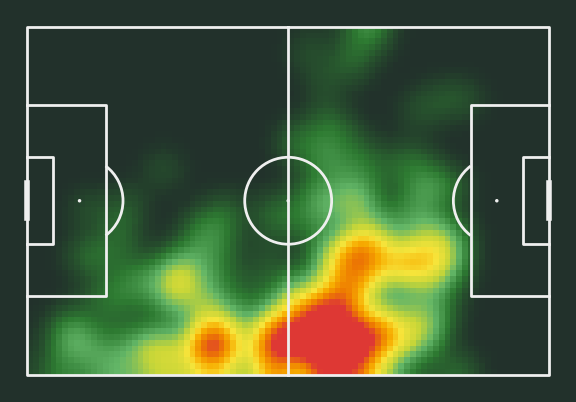

In [6]:
pitch = Pitch(
    pitch_type='statsbomb',
    pitch_color='#22312b',
    line_color='#efefef',
    line_zorder=2
)

fig, ax = pitch.draw(figsize=(6.6, 4.125))
fig.set_facecolor('#22312b')

bin_statistic = pitch.bin_statistic(
    df_lamine.x,
    df_lamine.y,
    statistic='count',
    bins=(90, 60)
)

bin_statistic['statistic'] = gaussian_filter(
    bin_statistic['statistic'],
    sigma=2.8
)

values = bin_statistic['statistic']
values = values[values > 0]

norm = Normalize(
    vmin=np.percentile(values, 5),
    vmax=np.percentile(values, 97)
)

pitch.heatmap(
    bin_statistic,
    ax=ax,
    cmap=sofascore_cmap,
    norm=norm,
    alpha=0.97,
    edgecolors='none'
)
plt.gca().invert_yaxis()
plt.show()


In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
import pandas as pd
from io import StringIO

options = Options()
options.add_argument("--disable-blink-features=AutomationControlled")

driver = webdriver.Chrome(options=options)
driver.get("https://fbref.com/en/comps/Big5/stats/players/Big-5-European-Leagues-Stats")

# Esperar a que haya tablas
WebDriverWait(driver, 30).until(
    lambda d: d.execute_script(
        "return document.querySelectorAll('table').length"
    ) > 0
)

# EXTRAER LA TABLA CORRECTA *ANTES* DE cerrar el driver
table_html = driver.execute_script("""
    const table = document.getElementById("stats_standard");
    return table ? table.outerHTML : null;
""")

driver.quit()  # ← AQUÍ, y solo aquí

if table_html is None:
    raise ValueError("No se pudo extraer stats_standard")




In [2]:
df = pd.read_html(StringIO(table_html))[0]

df.head()

Unnamed: 0_level_0   Unnamed: 1_level_0 Unnamed: 2_level_0  \
                  Rk               Player             Nation   
0                  1     Brenden Aaronson             us USA   
1                  2          Zach Abbott            eng ENG   
2                  3  Jones El-Abdellaoui             ma MAR   
3                  4        Himad Abdelli             dz ALG   
4                  5             Ali Abdi             tn TUN   

  Unnamed: 3_level_0 Unnamed: 4_level_0  Unnamed: 5_level_0  \
                 Pos              Squad                Comp   
0              FW,MF       Leeds United  eng Premier League   
1                 DF  Nottingham Forest  eng Premier League   
2              MF,FW         Celta Vigo          es La Liga   
3                 MF             Angers          fr Ligue 1   
4              MF,DF               Nice          fr Ligue 1   

  Unnamed: 6_level_0 Unnamed: 7_level_0 Playing Time         ... Performance  \
                 Age               Born           MP Starts  ...          PK   
0             25-096               2000           21     15  ...           0   
1             19-258               2006            1      0  ...           0   
2             20-014               2006           12      2  ...           0   
3             26-070               1999           13     11  ...           2   
4             32-037               1993           11      7  ...           0   

                  Per 90 Minutes                          Unnamed: 25_level_0  
  PKatt CrdY CrdR            Gls   Ast   G+A  G-PK G+A-PK             Matches  
0     0    1    0           0.27  0.20  0.47  0.27   0.47             Matches  
1     0    0    0           0.00  0.00  0.00  0.00   0.00             Matches  
2     0    0    0           0.48  0.00  0.48  0.48   0.48             Matches  
3     2    1    0           0.19  0.00  0.19  0.00   0.00             Matches  
4     0    4    1           0.00  0.00  0.00  0.00   0.00             Matches  

[5 rows x 26 columns]

In [489]:
df.columns = [
        col[1] if col[0].startswith("Unnamed") else f"{col[0]}_{col[1]}"
        for col in df.columns
    ]

In [490]:
cols_to_drop = ["Rk", "Matches"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
df

,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Per 90 Minutes_xG,Per 90 Minutes_xAG,Per 90 Minutes_xG+xAG,Per 90 Minutes_npxG,Per 90 Minutes_npxG+xAG
0,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25-089,2000,21,15,1334,...,0.27,0.20,0.47,0.27,0.47,0.21,0.20,0.41,0.21,0.41
1,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19-251,2006,1,0,45,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20-007,2006,11,1,288,...,0.62,0.00,0.62,0.62,0.62,0.70,0.02,0.73,0.70,0.73
3,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26-063,1999,13,11,943,...,0.19,0.00,0.19,0.00,0.00,0.19,0.04,0.23,0.04,0.08
4,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32-030,1993,10,6,485,...,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.09,0.00,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2572,Igor Zubeldia,es ESP,DF,Real Sociedad,es La Liga,28-295,1997,15,15,1350,...,0.00,0.07,0.07,0.00,0.07,0.01,0.05,0.06,0.01,0.06
2573,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,Gls,Ast,G+A,G-PK,G+A-PK,xG,xAG,xG+xAG,npxG,npxG+xAG
2574,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,26-351,1999,22,21,1847,...,0.15,0.05,0.19,0.15,0.19,0.10,0.05,0.15,0.10,0.15
2575,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27-033,1998,16,12,930,...,0.10,0.29,0.39,0.10,0.39,0.09,0.25,0.33,0.09,0.33


In [491]:
df[['Per 90 Minutes_xAG','Per 90 Minutes_xG', 'Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']]

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR
0,0.20,0.21,0.41,39,29,88
1,0.00,0.00,0.00,1,0,1
2,0.02,0.70,0.73,0,19,38
3,0.04,0.19,0.23,79,39,12
4,0.09,0.00,0.09,7,12,18
...,...,...,...,...,...,...
2572,0.05,0.01,0.06,48,5,0
2573,xAG,xG,xG+xAG,PrgP,PrgC,PrgR
2574,0.05,0.10,0.15,118,29,25
2575,0.25,0.09,0.33,102,27,27


In [492]:
df = df[df["Player"] != "Player"]
df = df.reset_index(drop=True)
df

,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Per 90 Minutes_xG,Per 90 Minutes_xAG,Per 90 Minutes_xG+xAG,Per 90 Minutes_npxG,Per 90 Minutes_npxG+xAG
0,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25-089,2000,21,15,1334,...,0.27,0.20,0.47,0.27,0.47,0.21,0.20,0.41,0.21,0.41
1,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19-251,2006,1,0,45,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,20-007,2006,11,1,288,...,0.62,0.00,0.62,0.62,0.62,0.70,0.02,0.73,0.70,0.73
3,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26-063,1999,13,11,943,...,0.19,0.00,0.19,0.00,0.00,0.19,0.04,0.23,0.04,0.08
4,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32-030,1993,10,6,485,...,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.09,0.00,0.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2473,Yanis Zouaoui,dz ALG,DF,Le Havre,fr Ligue 1,31-193,1994,17,16,1412,...,0.00,0.06,0.06,0.00,0.06,0.04,0.11,0.14,0.04,0.14
2474,Igor Zubeldia,es ESP,DF,Real Sociedad,es La Liga,28-295,1997,15,15,1350,...,0.00,0.07,0.07,0.00,0.07,0.01,0.05,0.06,0.01,0.06
2475,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,26-351,1999,22,21,1847,...,0.15,0.05,0.19,0.15,0.19,0.10,0.05,0.15,0.10,0.15
2476,Martin Ødegaard,no NOR,MF,Arsenal,eng Premier League,27-033,1998,16,12,930,...,0.10,0.29,0.39,0.10,0.39,0.09,0.25,0.33,0.09,0.33


In [59]:
df.to_csv(
    f"/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/clean/players_2025.csv",
    index=False
)

NameError: name 'df' is not defined

In [3]:
df_clean = pd.read_csv('/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/clean/players_2025.csv')

In [4]:
df_mf = (
    df_clean[
        (df_clean["Playing Time_Min"] >= 300) &
        (df_clean["Pos"].str.contains("MF"))
    ]
    .reset_index(drop=True)
)
df_mf

,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Per 90 Minutes_xG,Per 90 Minutes_xAG,Per 90 Minutes_xG+xAG,Per 90 Minutes_npxG,Per 90 Minutes_npxG+xAG
0,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25-089,2000.0,21,15,1334,...,0.27,0.20,0.47,0.27,0.47,0.21,0.20,0.41,0.21,0.41
1,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26-063,1999.0,13,11,943,...,0.19,0.00,0.19,0.00,0.00,0.19,0.04,0.23,0.04,0.08
2,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32-030,1993.0,10,6,485,...,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.09,0.00,0.09
3,Salis Abdul Samed,gh GHA,MF,Nice,fr Ligue 1,25-299,2000.0,12,7,528,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Laurent Abergel,fr FRA,MF,Lorient,fr Ligue 1,32-352,1993.0,17,17,1468,...,0.06,0.00,0.06,0.06,0.06,0.04,0.06,0.11,0.04,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
790,Alessio Zerbin,it ITA,"DF,MF",Cremonese,it Serie A,26-322,1999.0,15,9,826,...,0.00,0.22,0.22,0.00,0.22,0.11,0.16,0.27,0.11,0.27
791,Piotr Zieliński,pl POL,MF,Inter,it Serie A,31-244,1994.0,18,8,859,...,0.21,0.10,0.31,0.21,0.31,0.06,0.05,0.12,0.06,0.12
792,Joshua Zirkzee,nl NED,"FW,MF",Manchester Utd,eng Premier League,24-242,2001.0,14,4,490,...,0.37,0.18,0.55,0.37,0.55,0.36,0.17,0.52,0.36,0.52
793,Martín Zubimendi,es ESP,MF,Arsenal,eng Premier League,26-351,1999.0,22,21,1847,...,0.15,0.05,0.19,0.15,0.19,0.10,0.05,0.15,0.10,0.15


In [5]:
df_fw = (
    df_clean[
        (df_clean["Playing Time_Min"] >= 300) &
        (df_clean["Pos"].str.contains("FW"))
    ]
    .reset_index(drop=True)
)
df_fw

,Player,Nation,Pos,Squad,Comp,Age,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,...,Per 90 Minutes_Gls,Per 90 Minutes_Ast,Per 90 Minutes_G+A,Per 90 Minutes_G-PK,Per 90 Minutes_G+A-PK,Per 90 Minutes_xG,Per 90 Minutes_xAG,Per 90 Minutes_xG+xAG,Per 90 Minutes_npxG,Per 90 Minutes_npxG+xAG
0,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25-089,2000.0,21,15,1334,...,0.27,0.20,0.47,0.27,0.47,0.21,0.20,0.41,0.21,0.41
1,Matthis Abline,fr FRA,"FW,MF",Nantes,fr Ligue 1,22-297,2003.0,18,15,1428,...,0.19,0.13,0.32,0.19,0.32,0.25,0.11,0.36,0.20,0.31
2,Zakaria Aboukhlal,ma MAR,"DF,FW",Torino,it Serie A,25-335,2000.0,13,5,446,...,0.00,0.00,0.00,0.00,0.00,0.07,0.03,0.10,0.07,0.10
3,Giorgi Abuashvili,ge GEO,"FW,MF",Metz,fr Ligue 1,22-345,2003.0,11,4,307,...,0.29,0.00,0.29,0.29,0.29,0.10,0.05,0.15,0.10,0.15
4,Ragnar Ache,de GER,FW,Köln,de Bundesliga,27-175,1998.0,17,6,749,...,0.36,0.36,0.72,0.36,0.72,0.58,0.20,0.78,0.58,0.78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,Nicolò Zaniolo,it ITA,FW,Udinese,it Serie A,26-201,1999.0,18,16,1221,...,0.37,0.15,0.52,0.37,0.52,0.27,0.14,0.41,0.27,0.41
581,Duván Zapata,co COL,FW,Torino,it Serie A,34-293,1991.0,15,5,529,...,0.17,0.17,0.34,0.17,0.34,0.29,0.05,0.34,0.16,0.21
582,Bryan Zaragoza,es ESP,"FW,MF",Celta Vigo,es La Liga,24-132,2001.0,18,12,1041,...,0.09,0.09,0.17,0.00,0.09,0.08,0.22,0.30,0.08,0.30
583,Joshua Zirkzee,nl NED,"FW,MF",Manchester Utd,eng Premier League,24-242,2001.0,14,4,490,...,0.37,0.18,0.55,0.37,0.55,0.36,0.17,0.52,0.36,0.52


In [6]:
cols_calc = ['Progression_PrgP','Progression_PrgC','Progression_PrgR']
den = 'Playing Time_90s'

In [7]:
df_mf[cols_calc] = df_mf[cols_calc].div(df_mf[den], axis=0).round(2)



In [8]:
df_fw[cols_calc] = df_fw[cols_calc].div(df_fw[den], axis=0).round(2)

In [9]:
def get_user_percentile(df, player, cols):
    df_player = df.copy()
    df_player = df_player[df_player['Player'] == player]
    df_player = df_player[cols]
    for col in cols:
        valor_player = df_player[col].iloc[0]
        df_player.loc[:, col] = (df[col] <= valor_player).mean() * 100

        df_player = df_player.round(1)
    
    df_player['player']=player
    return df_player
    

In [10]:
columnas = ['Per 90 Minutes_xAG','Per 90 Minutes_xG', 'Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
df_percentile_pedri = get_user_percentile(df_mf, 'Pedri', columnas )
df_percentile_pedri

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
572,93.8,48.9,80.0,99.9,95.7,56.9,Pedri


In [11]:
columnas = ['Per 90 Minutes_xAG','Per 90 Minutes_xG', 'Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
df_percentile_maxime = get_user_percentile(df_mf, 'Maxime Lopez', columnas )
df_percentile_maxime

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
421,94.3,2.1,65.3,98.5,86.2,42.6,Maxime Lopez


In [12]:
columnas = ['Per 90 Minutes_xAG','Per 90 Minutes_xG', 'Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
df_percentile_ounahi = get_user_percentile(df_mf, 'Azzedine Ounahi', columnas )
df_percentile_ounahi

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
555,74.7,48.9,65.3,96.7,91.7,75.2,Azzedine Ounahi


In [13]:
columnas = ['Per 90 Minutes_xAG','Per 90 Minutes_xG', 'Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
df_percentile_edu = get_user_percentile(df_mf, 'Edu Expósito', columnas )
df_percentile_edu

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
216,95.8,48.9,80.0,94.0,67.7,44.4,Edu Expósito


In [14]:
df_final_mf = pd.concat([df_percentile_pedri, df_percentile_maxime, df_percentile_ounahi, df_percentile_edu], ignore_index=True)
df_final_mf


,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
0,93.8,48.9,80.0,99.9,95.7,56.9,Pedri
1,94.3,2.1,65.3,98.5,86.2,42.6,Maxime Lopez
2,74.7,48.9,65.3,96.7,91.7,75.2,Azzedine Ounahi
3,95.8,48.9,80.0,94.0,67.7,44.4,Edu Expósito


In [15]:
columnas = ['Per 90 Minutes_xAG','Per 90 Minutes_xG', 'Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
df_percentile_lamine = get_user_percentile(df_fw, 'Lamine Yamal', columnas )
df_percentile_lamine

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
577,97.6,77.9,95.9,93.0,99.3,94.4,Lamine Yamal


In [16]:
df_percentile_felix = get_user_percentile(df_fw, 'Félix Correia', columnas )
df_percentile_felix

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
112,92.1,41.9,71.8,95.7,67.2,92.3,Félix Correia


In [17]:
df_percentile_jacob = get_user_percentile(df_fw, 'Jacob Murphy', columnas )
df_percentile_jacob

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
384,94.7,41.9,82.6,72.3,68.5,96.9,Jacob Murphy


In [18]:
df_final_fw = pd.concat([df_percentile_lamine, df_percentile_felix, df_percentile_jacob], ignore_index=True)
df_final_fw

,Per 90 Minutes_xAG,Per 90 Minutes_xG,Per 90 Minutes_xG+xAG,Progression_PrgP,Progression_PrgC,Progression_PrgR,player
0,97.6,77.9,95.9,93.0,99.3,94.4,Lamine Yamal
1,92.1,41.9,71.8,95.7,67.2,92.3,Félix Correia
2,94.7,41.9,82.6,72.3,68.5,96.9,Jacob Murphy


In [19]:
URL1 = ('https://raw.githubusercontent.com/googlefonts/SourceSerifProGFVersion/main/fonts/'
        'SourceSerifPro-Regular.ttf')
serif_regular = FontManager(URL1)
URL2 = ('https://raw.githubusercontent.com/googlefonts/SourceSerifProGFVersion/main/fonts/'
        'SourceSerifPro-ExtraLight.ttf')
serif_extra_light = FontManager(URL2)
URL3 = ('https://raw.githubusercontent.com/google/fonts/main/ofl/rubikmonoone/'
        'RubikMonoOne-Regular.ttf')
rubik_regular = FontManager(URL3)
URL4 = 'https://raw.githubusercontent.com/googlefonts/roboto/main/src/hinted/Roboto-Thin.ttf'
robotto_thin = FontManager(URL4)
URL5 = ('https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/'
        'RobotoSlab%5Bwght%5D.ttf')
robotto_bold = FontManager(URL5)

roboto_slab_regular = FontProperties(
    fname=robotto_bold.prop.get_file(),
    weight=200
)


In [20]:
BARCA_BLAU = "#004D98"
BARCA_GRANA = "#A50044"
BARCA_GRAY = "#E5E5E5"
BARCA_GOLD = "#edbb00"

In [21]:

def radar_jugador(df, player, pos, team, labels):
    metrics = ['Per 90 Minutes_xAG','Per 90 Minutes_xG','Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
    labels  = labels
  
    low = [0, 0, 0, 0, 0, 0]
    high = [100, 100, 100, 100, 100, 100]
    val_0 = df[metrics].iloc[0].to_numpy()
    radar = Radar(labels, low, high,
              num_rings=4,  # the number of concentric circles (excluding center circle)
              # if the ring_width is more than the center_circle_radius then
              # the center circle radius will be wider than the width of the concentric circles
              ring_width=1, center_circle_radius=1)
    # creating the figure using the grid function from mplsoccer:
    fig, axs = grid(figheight=7, grid_height=0.915, title_height=0.06, endnote_height=0.025,
                    title_space=0, endnote_space=0, grid_key='radar', axis=False)

    # plot the radar
    radar.setup_axis(ax=axs['radar'], facecolor='None')
    rings_inner = radar.draw_circles(ax=axs['radar'], facecolor='#28252c', edgecolor='#39353f', lw=1.5)
    radar_output = radar.draw_radar(val_0, ax=axs['radar'],
                                            kwargs_radar={'facecolor': BARCA_GRANA, 'alpha': 0.6},
                                            kwargs_rings={'facecolor': BARCA_BLAU, 'alpha': 0.6})
    radar_poly, rings_outer, vertices = radar_output
    range_labels = radar.draw_range_labels(ax=axs['radar'], fontsize=10, color = BARCA_GRAY,
                                        fontproperties=robotto_thin.prop)
    param_labels = radar.draw_param_labels(ax=axs['radar'], fontsize=12, color = BARCA_GRAY,
                                        fontproperties=robotto_bold.prop)

    # adding the endnote and title text (these axes range from 0-1, i.e. 0, 0 is the bottom left)
    # Note we are slightly offsetting the text from the edges by 0.01 (1%, e.g. 0.99)

    title1_text = axs['title'].text(0.01, 0.65, player, fontsize=23,
                                    fontproperties=robotto_bold.prop,
                                    ha='left', va='center', color=BARCA_BLAU)
    title2_text = axs['title'].text(0.01, 0.001, team, fontsize=20,
                                    fontproperties=robotto_thin.prop,
                                    ha='left', va='center', color=BARCA_GRANA)
    title3_text = axs['title'].text(0.99, 0.65, 'Radar Chart', fontsize=23,
                                    fontproperties=robotto_bold.prop,
                                    ha='right', va='center', color=BARCA_BLAU)
    title4_text = axs['title'].text(0.99, 0.001, pos, fontsize=20,
                                    fontproperties=robotto_thin.prop,
                                    ha='right', va='center', color=BARCA_GRANA)

    fig.set_facecolor('#121212')

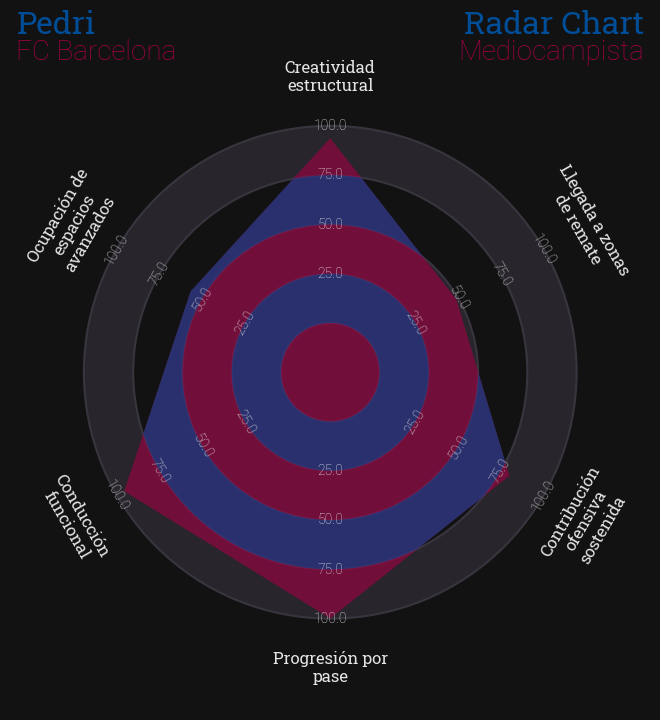

In [22]:
player='Pedri'
pos='Mediocampista'
team='FC Barcelona'
labels  = ["Creatividad estructural", "Llegada a zonas de remate", "Contribución ofensiva sostenida", "Progresión por pase", "Conducción funcional", "Ocupación de espacios avanzados"]
radar_jugador(df_percentile_pedri, player, pos, team, labels )

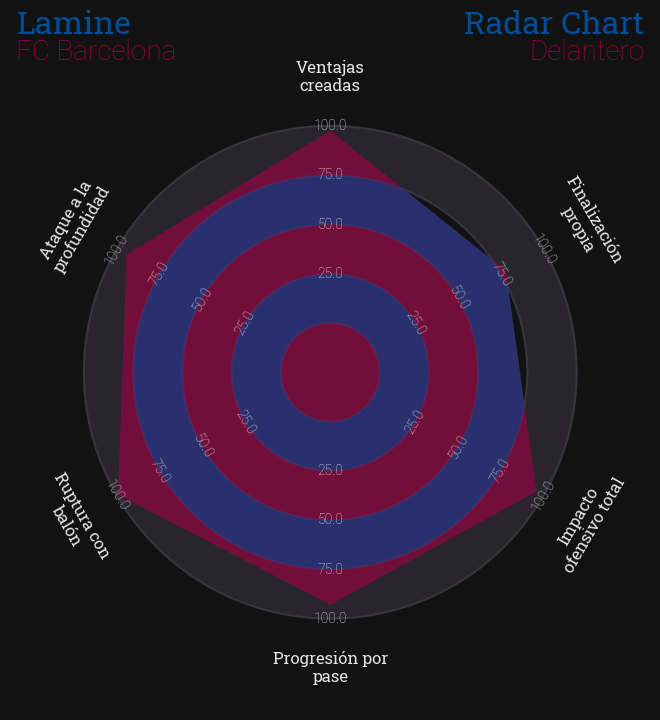

In [23]:
player='Lamine'
pos='Delantero'
team='FC Barcelona'
labels  = ["Ventajas creadas", "Finalización propia", "Impacto ofensivo total", "Progresión por pase", "Ruptura con balón", "Ataque a la profundidad"]
radar_jugador(df_percentile_lamine, player, pos, team, labels)

In [24]:
def radar_jugadores(df, labels,player1):
    metrics = ['Per 90 Minutes_xAG','Per 90 Minutes_xG','Per 90 Minutes_xG+xAG','Progression_PrgP','Progression_PrgC','Progression_PrgR']
    labels  = labels
    
    low = [0, 0, 0, 0, 0, 0]
    high = [100, 100, 100, 100, 100, 100]
    val_0 = df[metrics].iloc[0].to_numpy()
    val_1 = df[metrics].iloc[2].to_numpy()
    
    radar = Radar(labels, low, high,
              num_rings=4,  # the number of concentric circles (excluding center circle)
              # if the ring_width is more than the center_circle_radius then
              # the center circle radius will be wider than the width of the concentric circles
              ring_width=1, center_circle_radius=1)
    # creating the figure using the grid function from mplsoccer:
    fig, axs = grid(figheight=7, grid_height=0.915, title_height=0.06, endnote_height=0.025,
                    title_space=0, endnote_space=0, grid_key='radar', axis=False)

    # plot the radar
    radar.setup_axis(ax=axs['radar'], facecolor='None')
    rings_inner = radar.draw_circles(ax=axs['radar'], facecolor='#28252c', edgecolor='#39353f', lw=1.5)
    radar_output = radar.draw_radar_compare(val_0, val_1, ax=axs['radar'],
                                            kwargs_radar={'facecolor': BARCA_GRANA, 'alpha': 0.6},
                                            kwargs_compare={'facecolor': BARCA_BLAU, 'alpha': 0.6})
    radar_poly, radar_poly2, vertices1, vertices2 = radar_output
    range_labels = radar.draw_range_labels(ax=axs['radar'], fontsize=10, color = BARCA_GRAY,
                                        fontproperties=robotto_thin.prop)
    param_labels = radar.draw_param_labels(ax=axs['radar'], fontsize=12, color = BARCA_GRAY,
                                        fontproperties=robotto_bold.prop)
    axs['radar'].scatter(vertices1[:, 0], vertices1[:, 1],
                        c= BARCA_GRANA, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)
    axs['radar'].scatter(vertices2[:, 0], vertices2[:, 1],
                        c= BARCA_BLAU, edgecolors='#6d6c6d', marker='o', s=150, zorder=2)

    # adding the endnote and title text (these axes range from 0-1, i.e. 0, 0 is the bottom left)
    # Note we are slightly offsetting the text from the edges by 0.01 (1%, e.g. 0.99)

    title1_text = axs['title'].text(0.01, 0.65, 'Lamine', fontsize=20, fontproperties=robotto_bold.prop, ha='left', va='center', color=BARCA_GRANA) 
    title2_text = axs['title'].text(0.01, 0.00, '2025-2026', fontsize=15, fontproperties=robotto_thin.prop, ha='left', va='center', color='#FFFFFF') 
    title3_text = axs['title'].text(0.99, 0.65, player1, fontsize=20, fontproperties=robotto_bold.prop, ha='right', va='center', color=BARCA_BLAU) 
    title4_text = axs['title'].text(0.99, 0.00, '2025-2026', fontsize=15, fontproperties=robotto_thin.prop, ha='right', va='center', color='#FFFFFF')

    fig.set_facecolor('#121212')
    

In [25]:
['Félix Correia',
        'Jacob Murphy']

['Félix Correia', 'Jacob Murphy']

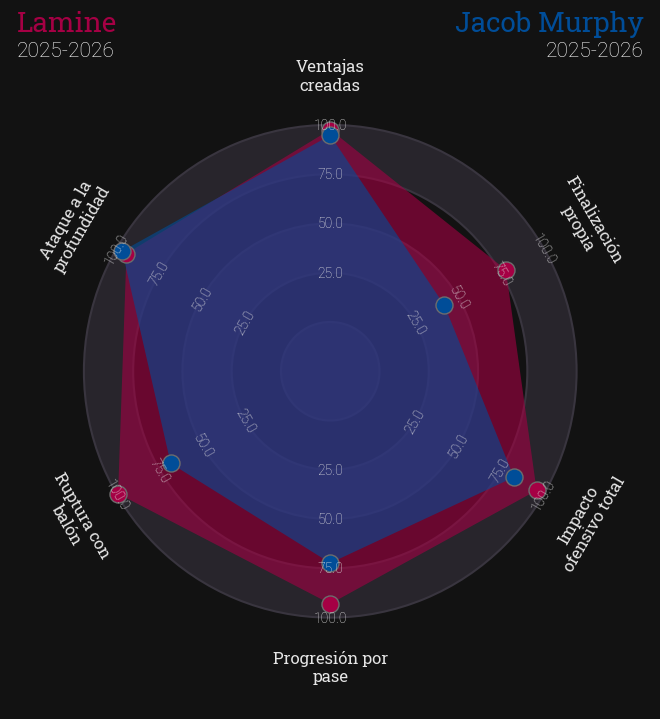

In [26]:
player = 'Jacob Murphy'
labels  = ["Ventajas creadas", "Finalización propia", "Impacto ofensivo total", "Progresión por pase", "Ruptura con balón", "Ataque a la profundidad"]
radar_jugadores(df_final_fw, labels, player)

In [27]:
def radar__mas_jugadores(df, player_base, players_compare, labels):

    metrics = [
        'Per 90 Minutes_xAG',
        'Per 90 Minutes_xG',
        'Per 90 Minutes_xG+xAG',
        'Progression_PrgP',
        'Progression_PrgC',
        'Progression_PrgR'
    ]

    low  = [0] * len(metrics)
    high = [100] * len(metrics)

    base_vals = df.loc[df['player'] == player_base, metrics].iloc[0].to_numpy()
    compare_vals = [
        df.loc[df['player'] == p, metrics].iloc[0].to_numpy()
        for p in players_compare
    ]

    compare_colors = [BARCA_BLAU, BARCA_GOLD, BARCA_GRAY]

    radar = Radar(
        labels,
        low,
        high,
        num_rings=4,
        ring_width=1,
        center_circle_radius=1
    )

    # --- GRID (versión estable) ---
    fig, axs = grid(
        figheight=7,
        grid_height=0.90,
        title_height=0.08,
        endnote_height=0.02,
        title_space=0,
        endnote_space=0,
        grid_key='radar',
        axis=False
    )

    radar.setup_axis(ax=axs['radar'], facecolor='None')

    # 1) Círculos base
    radar.draw_circles(
        ax=axs['radar'],
        facecolor=BARCA_GRAY,
        alpha=0.06,
        edgecolor=BARCA_GRAY,
        lw=1.4
    )

    # -------------------------------------------------
    # 2) PEDRI — EFECTO BLAUGRANA (DOS CAPAS)
    # -------------------------------------------------

    # PEDRI — ÁREA GRANA (SIMPLE Y LIMPIO)
    radar.draw_radar(
        base_vals,
        ax=axs['radar'],
        kwargs_radar={
            'facecolor': BARCA_GRANA,
            'alpha': 0.35
        },
        kwargs_rings={'facecolor': 'none'}
    )


    # -------------------------------------------------
    # 3) COMPARADOS — SOLO LÍNEAS
    # -------------------------------------------------
    for vals, color in zip(compare_vals, compare_colors):
        radar.draw_radar(
            vals,
            ax=axs['radar'],
            kwargs_radar={
                'fill': False,
                'edgecolor': color,
                'lw': 2.4,
                'alpha': 0.95
            },
            kwargs_rings={'facecolor': 'none'}
        )

    # 4) Labels
    radar.draw_range_labels(
        ax=axs['radar'],
        fontsize=10,
        color=BARCA_GRAY,
        fontproperties=robotto_thin.prop
    )

    radar.draw_param_labels(
        ax=axs['radar'],
        fontsize=12,
        color=BARCA_GRAY,
        fontproperties=robotto_thin.prop
    )

    # =================================================
    # HEADER — POSICIONES MANUALES (SIN SOLAPES)
    # =================================================
    y = 0.62

    axs['title'].text(
        0.04, 0.61, player_base,
        fontsize=18,
        fontproperties=robotto_thin.prop,
        color=BARCA_GRANA,
        ha='left', va='center'
    )

    axs['title'].text(
        0.16, y, players_compare[0],
        fontsize=18,
        fontproperties=robotto_thin.prop,
        color=BARCA_BLAU,
        ha='left', va='center'
    )

    axs['title'].text(
        0.44, y, players_compare[1],
        fontsize=18,
        fontproperties=robotto_thin.prop,
        color=BARCA_GOLD,
        ha='left', va='center'
    )

    axs['title'].text(
        0.75, y, players_compare[2],
        fontsize=18,
        fontproperties=robotto_thin.prop,
        color=BARCA_GRAY,
        ha='left', va='center'
    )

    fig.set_facecolor('#121212')


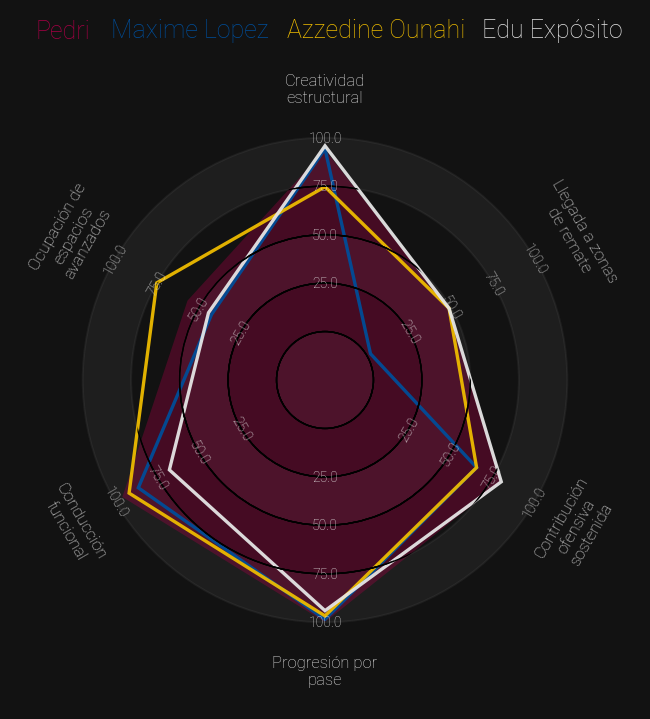

In [28]:
labels  = ["Creatividad estructural", "Llegada a zonas de remate", "Contribución ofensiva sostenida", "Progresión por pase", "Conducción funcional", "Ocupación de espacios avanzados"]

radar__mas_jugadores(
    df=df_final_mf,
    player_base='Pedri',
    players_compare=['Maxime Lopez',
        'Azzedine Ounahi',
        'Edu Expósito'],
    labels=labels
)


configuracion para tableau

In [31]:
df_long = df_percentile_lamine.melt(
    id_vars="player",
    var_name="Metric",
    value_name="Percentile"
)

df_long


,player,Metric,Percentile
0,Lamine Yamal,Per 90 Minutes_xAG,97.6
1,Lamine Yamal,Per 90 Minutes_xG,77.9
2,Lamine Yamal,Per 90 Minutes_xG+xAG,95.9
3,Lamine Yamal,Progression_PrgP,93.0
4,Lamine Yamal,Progression_PrgC,99.3
5,Lamine Yamal,Progression_PrgR,94.4


In [32]:
metric_map = {
    "Per 90 Minutes_xAG": "xAG / 90",
    "Per 90 Minutes_xG": "xG / 90",
    "Per 90 Minutes_xG+xAG": "xG+xAG / 90",
    "Progression_PrgP": "Progressive Passes",
    "Progression_PrgC": "Progressive Carries",
    "Progression_PrgR": "Progressive Receives"
}

df_long["Metric"] = df_long["Metric"].map(metric_map)


In [33]:
df_long.to_excel(
    "/home/fjordan/Documentos/Proyectos/Personales/proyectos-Python/Analisis Lamine-Pedri/data/clean/lamine_percentile_profile.xlsx",
    index=False
)